# 📈 CN7030 — Big Data Analytics
## Guided Lab: Advanced Time-Series Forecasting in PySpark

### FinTech Track — Apple Inc. (AAPL) Stock Price Forecasting
**Prepared by Dr. Mustansar Ali Ghazanfar**

---

> **Module:** CN7030 — Big Data  
> **Dataset:** Apple Inc. (AAPL) daily stock data — 1999–2024  
> **Tools:** PySpark MLlib, Pandas, Matplotlib, Seaborn

---

## 🎯 What This Lab Shows

By the end of this lab you will have combined **rich Exploratory Data Analysis (EDA)** with rigorous **Financial Machine Learning** standards:

| Step | Phase | Description |
|------|-------|-------------|
| 📥 **1** | **Ingestion** | Load AAPL financial data into Colab and Spark |
| 🔍 **2** | **Deep EDA** | Build dual-axis Price/Volume charts, Return Distributions, and Correlation Heatmaps |
| ⚙️ **3** | **Stationarity**| Engineer Daily Returns to avoid the dangerous "Random Walk" ML trap |
| 🧠 **4** | **Pipelines** | Build production PySpark ML Pipelines using `StandardScaler` and `VectorAssembler` |
| 📊 **5** | **Evaluation** | Evaluate models using both Regression (RMSE) and Trading (Directional Accuracy) metrics |

> **Recommended workflow:** Run the notebook **top to bottom**, one cell at a time. Pay close attention to the reflection questions at the end.


## ⚙️ 1. Lab Setup & Data Loading
Let's initialize our environment. We will use `pandas` and `seaborn` for rich local visualisations before transitioning the heavy lifting to `PySpark`.

In [1]:
# Install PySpark inside Colab
!pip -q install pyspark

# Core Python libraries
import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# PySpark imports
from pyspark.sql import SparkSession, Window
from pyspark.sql.functions import col, to_date, lag, lead, avg, stddev, row_number, month, dayofweek, signum
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression, GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator

# Plotting aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (14, 6)

print("✅ Setup complete. Libraries imported.")



[notice] A new release of pip is available: 24.3.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
✅ Setup complete. Libraries imported.


In [2]:
# from google.colab import files
default_path = '/Users/wizrdm/Desktop/UEL/Machine Learning on Big Data/aapl_stock_data.csv'

if os.path.exists(default_path):
    data_file = default_path
    print("File found locally.")
else:
    print("Please upload aapl_stock_data.csv")
    # uploaded = files.upload()
    # csv_files = [f for f in uploaded.keys() if f.lower().endswith(".csv")]
    # data_file = f"/content/{csv_files[0]}"

# Load to Pandas for EDA
pdf = pd.read_csv(data_file)
pdf["Date"] = pd.to_datetime(pdf["Date"])
pdf = pdf.sort_values("Date").reset_index(drop=True)
print(f"✅ Data loaded: {pdf.shape[0]:,} rows. Range: {pdf['Date'].min().date()} to {pdf['Date'].max().date()}")


File found locally.
✅ Data loaded: 6,213 rows. Range: 1999-11-01 to 2024-07-12


## 📊 2. Deep Exploratory Data Analysis (EDA)
Before building Machine Learning models, we must understand the statistical properties of our data. Financial time-series data is notoriously noisy, non-stationary, and prone to extreme outliers (fat tails).

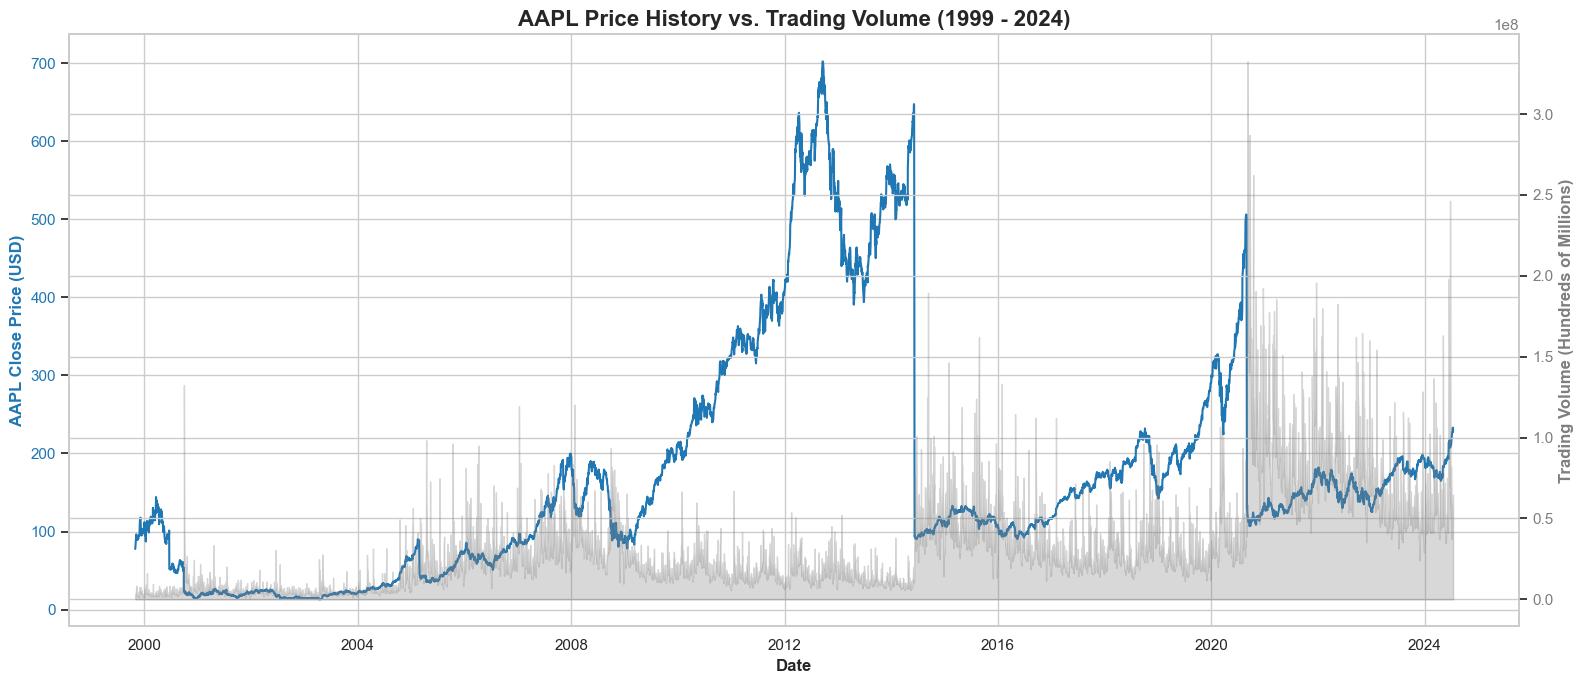

In [3]:
# 2.1 Dual-Axis Plot: Historical Price & Trading Volume
fig, ax1 = plt.subplots(figsize=(16, 7))

color = 'tab:blue'
ax1.set_xlabel('Date', fontweight='bold')
ax1.set_ylabel('AAPL Close Price (USD)', color=color, fontweight='bold')
ax1.plot(pdf['Date'], pdf['Close'], color=color, linewidth=1.5)
ax1.tick_params(axis='y', labelcolor=color)

# Instantiate a second axes that shares the same x-axis for Volume
ax2 = ax1.twinx()
color = 'tab:grey'
ax2.set_ylabel('Trading Volume (Hundreds of Millions)', color=color, fontweight='bold')
ax2.fill_between(pdf['Date'], pdf['Volume'], color=color, alpha=0.3)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('AAPL Price History vs. Trading Volume (1999 - 2024)', fontsize=16, fontweight='bold')
fig.tight_layout()
plt.savefig('aapl_price_volume.png')
plt.show()


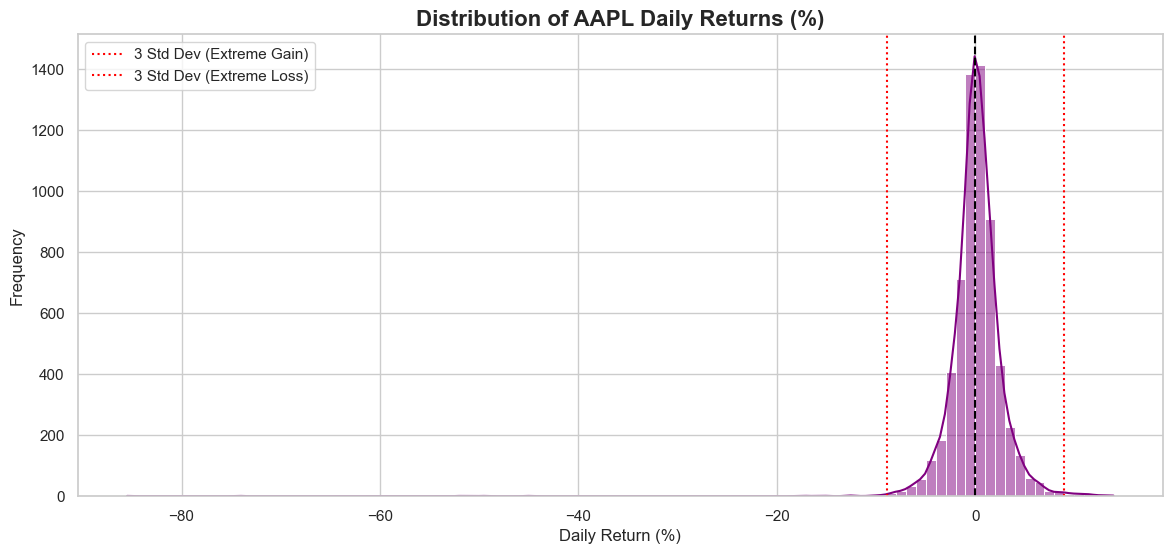

In [4]:
# 2.2 Distribution of Daily Returns (Checking for Fat Tails / Kurtosis)
pdf['Daily_Return'] = pdf['Close'].pct_change() * 100 # Converted to percentage

plt.figure(figsize=(14, 6))
sns.histplot(pdf['Daily_Return'].dropna(), bins=100, kde=True, color="purple")
plt.title("Distribution of AAPL Daily Returns (%)", fontsize=16, fontweight='bold')
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")
plt.axvline(0, color='black', linestyle='--')

# Annotating standard deviations to show market extremes
std_dev = pdf['Daily_Return'].std()
plt.axvline(std_dev * 3, color='red', linestyle=':', label='3 Std Dev (Extreme Gain)')
plt.axvline(-std_dev * 3, color='red', linestyle=':', label='3 Std Dev (Extreme Loss)')
plt.legend()
plt.savefig('aapl_returns_distribution.png')
plt.show()


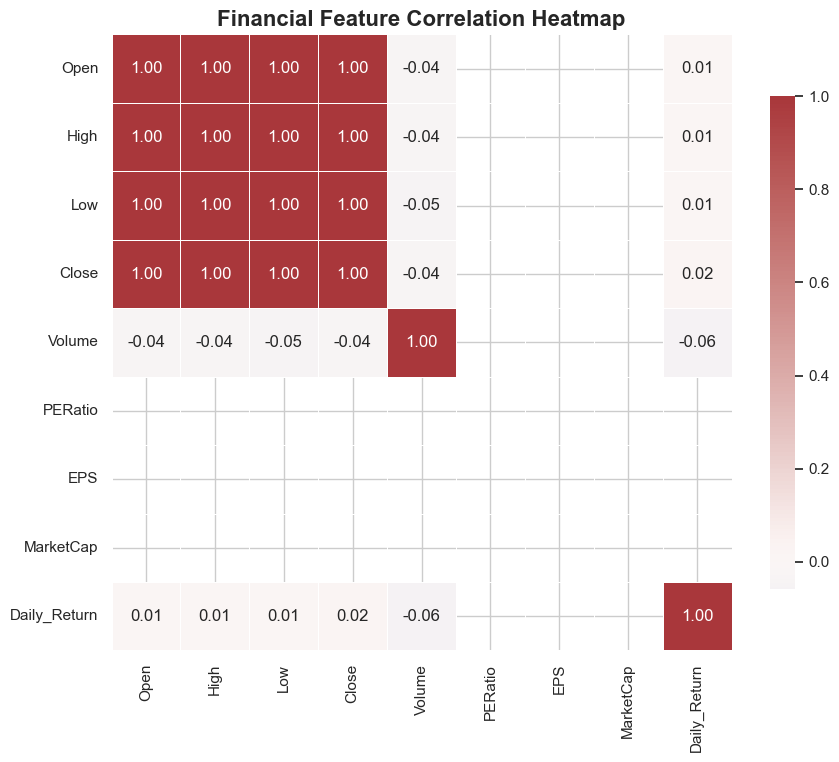

In [5]:
# 2.3 Feature Correlation Heatmap
# This helps us spot multicollinearity. Notice how Open, High, Low, and Close are perfectly correlated.
plt.figure(figsize=(10, 8))
corr_matrix = pdf[['Open', 'High', 'Low', 'Close', 'Volume', 'PERatio', 'EPS', 'MarketCap', 'Daily_Return']].corr()
sns.heatmap(corr_matrix, annot=True, cmap="vlag", center=0, fmt=".2f", linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Financial Feature Correlation Heatmap", fontsize=16, fontweight='bold')
plt.savefig('aapl_correlation.png')
plt.show()


## 🚀 3. PySpark Initialization & Feature Engineering
Now we transition to **PySpark** to handle the data in a distributed manner.

**The "Random Walk" Trap:** Beginners often try to predict `Next_Close_Price`. Because stock prices follow a random walk, models just learn to output today's price as tomorrow's prediction. The RMSE looks great, but the model is utterly useless for trading.
 We must engineer stationary features and predict `Target_Next_Return` (percentage change).

In [6]:
spark = SparkSession.builder.appName("MSc_FinTech_Forecasting_Advanced").getOrCreate()
spark_df = spark.read.csv(data_file, header=True, inferSchema=True)

df = (
    spark_df.select(
        to_date(col("Date"), "yyyy-MM-dd").alias("Date"),
        col("Close").cast("double"), col("Volume").cast("double"),
        col("PERatio").cast("double"), col("EPS").cast("double"),
        col("MarketCap").cast("double")
    ).dropna().orderBy("Date")
)


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/05/03 11:55:34 WARN Utils: Your hostname, Wizrds-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 10.136.11.24 instead (on interface en0)
26/05/03 11:55:34 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/03 11:55:35 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [7]:
# Distributed Window Functions for Lag & Volatility Features
time_window = Window.orderBy("Date")
rolling_5 = time_window.rowsBetween(-4, 0)
rolling_20 = time_window.rowsBetween(-19, 0) # Monthly moving averages

features_df = (
    df.withColumn("Daily_Return", (col("Close") - lag("Close", 1).over(time_window)) / lag("Close", 1).over(time_window))
      .withColumn("Lag_1_Return", lag("Daily_Return", 1).over(time_window))
      .withColumn("Lag_2_Return", lag("Daily_Return", 2).over(time_window))
      .withColumn("RollingStd_5", stddev("Daily_Return").over(rolling_5)) # Short-term Volatility
      .withColumn("RollingStd_20", stddev("Daily_Return").over(rolling_20)) # Long-term Volatility
      .withColumn("Month", month("Date"))
      .withColumn("DayOfWeek", dayofweek("Date"))
      # OUR ML TARGET: Predict tomorrow's return
      .withColumn("Target_Next_Return", lead("Daily_Return", 1).over(time_window))
      .dropna()
)

print("✅ Stationary Feature Engineering Complete. Preview:")
features_df.select("Date", "Close", "Daily_Return", "Lag_1_Return", "RollingStd_5", "Target_Next_Return").show(5)


✅ Stationary Feature Engineering Complete. Preview:


26/05/03 11:55:42 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 11:55:42 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 11:55:42 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 11:55:42 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 11:55:42 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 11:55:43 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 1

+----------+-----+--------------------+--------------------+--------------------+--------------------+
|      Date|Close|        Daily_Return|        Lag_1_Return|        RollingStd_5|  Target_Next_Return|
+----------+-----+--------------------+--------------------+--------------------+--------------------+
|1999-11-04|83.62|0.026012269938650363| 0.01557632398753894|0.009183252736653973|0.056087060511839246|
|1999-11-05|88.31|0.056087060511839246|0.026012269938650363| 0.01718678030944068| 0.09126939191484545|
|1999-11-08|96.37| 0.09126939191484545|0.056087060511839246| 0.03005291138355713| -0.0700425443602781|
|1999-11-09|89.62| -0.0700425443602781| 0.09126939191484545| 0.06015296613246108|0.020307966971658035|
|1999-11-10|91.44|0.020307966971658035| -0.0700425443602781| 0.06002872151496396|0.008858267716535459|
+----------+-----+--------------------+--------------------+--------------------+--------------------+
only showing top 5 rows


## ✂️ 4. Chronological Train-Test Split
We **cannot** use random train-test splits (like `df.randomSplit()`) in finance. Shuffling time-series data causes future data to leak into the training set, ruining the model's validity.

In [8]:
features_df = features_df.withColumn("row_num", row_number().over(time_window))
total_rows = features_df.count()
split_index = int(total_rows * 0.8)

train_df = features_df.filter(col("row_num") <= split_index)
test_df = features_df.filter(col("row_num") > split_index)

print(f"🎓 Training Data: {train_df.count()} rows (Past)")
print(f"🧪 Testing Data: {test_df.count()} rows (Future)")


26/05/03 11:55:44 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 11:55:44 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 11:55:44 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 11:55:44 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 11:55:45 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 11:55:45 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 1

🎓 Training Data: 4967 rows (Past)


26/05/03 11:55:45 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 11:55:45 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 11:55:45 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 11:55:45 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 11:55:45 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 11:55:45 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


🧪 Testing Data: 1242 rows (Future)


26/05/03 11:55:46 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 11:55:46 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 11:55:46 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 11:55:46 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 11:55:46 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 11:55:46 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 1

## 🧠 5. Production PySpark ML Pipelines
We use `pyspark.ml.Pipeline` to chain our feature assembly and scaling.

**Why Scale?** Features like `Volume` are in the millions, while `Lag_1_Return` is a tiny decimal (e.g., 0.012). Without a `StandardScaler`, gradient descent in Linear Regression will completely fail or heavily bias towards Volume.

In [9]:
feature_cols = [
    "Volume", "PERatio", "EPS", "MarketCap",
    "Lag_1_Return", "Lag_2_Return",
    "RollingStd_5", "RollingStd_20", "Month", "DayOfWeek"
]

# 1. Pipeline Stages
assembler = VectorAssembler(inputCols=feature_cols, outputCol="raw_features")
scaler = StandardScaler(inputCol="raw_features", outputCol="scaled_features", withStd=True, withMean=True)

# 2. Estimators (Models)
lr = LinearRegression(featuresCol="scaled_features", labelCol="Target_Next_Return", predictionCol="lr_prediction")
gbt = GBTRegressor(featuresCol="raw_features", labelCol="Target_Next_Return", predictionCol="gbt_prediction", maxIter=40, maxDepth=5)

# 3. Assemble Pipelines
lr_pipeline = Pipeline(stages=[assembler, scaler, lr])
gbt_pipeline = Pipeline(stages=[assembler, gbt])

print("✅ ML Pipelines constructed.")


✅ ML Pipelines constructed.


In [10]:
print("🏋️ Training Linear Regression Model...")
lr_model = lr_pipeline.fit(train_df)
lr_predictions = lr_model.transform(test_df)

print("🌲 Training Gradient Boosted Trees Model...")
gbt_model = gbt_pipeline.fit(train_df)
gbt_predictions = gbt_model.transform(test_df)
print("✅ Distributed Training complete.")


🏋️ Training Linear Regression Model...


26/05/03 11:55:46 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 11:55:46 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 11:55:46 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 11:55:46 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 11:55:46 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 11:55:46 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 1

🌲 Training Gradient Boosted Trees Model...


26/05/03 11:55:50 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 11:55:50 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 11:55:50 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 11:55:50 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 11:55:50 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 11:55:50 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 1

✅ Distributed Training complete.


## 🎯 6. Financial Evaluation: Directional Accuracy vs. RMSE
In algorithmic trading, getting the *direction* of the trade right (Up/Down) is often more profitable than minimizing the absolute numerical error (RMSE).

In [11]:
def evaluate_financial_model(predictions_df, prediction_col, model_name):
    # Regression Error (RMSE)
    rmse_eval = RegressionEvaluator(labelCol="Target_Next_Return", predictionCol=prediction_col, metricName="rmse")
    rmse = rmse_eval.evaluate(predictions_df)

    # Directional Accuracy (Did we correctly guess if the return would be positive or negative?)
    dir_df = predictions_df.withColumn("Actual_Sign", signum(col("Target_Next_Return")))\
                           .withColumn("Pred_Sign", signum(col(prediction_col)))

    correct = dir_df.filter(col("Actual_Sign") == col("Pred_Sign")).count()
    total = dir_df.count()
    dir_accuracy = (correct / total) * 100

    return {"Model": model_name, "RMSE": round(rmse, 4), "Directional Accuracy (%)": round(dir_accuracy, 2)}

results = pd.DataFrame([
    evaluate_financial_model(lr_predictions, "lr_prediction", "Linear Regression (Scaled)"),
    evaluate_financial_model(gbt_predictions, "gbt_prediction", "Gradient-Boosted Trees"),
])
display(results)


26/05/03 11:56:02 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 11:56:02 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 11:56:02 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 11:56:02 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 11:56:02 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 11:56:02 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 1

,Model,RMSE,Directional Accuracy (%)
0,Linear Regression (Scaled),0.0291,53.22
1,Gradient-Boosted Trees,0.0311,51.05


26/05/03 11:56:05 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 11:56:05 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 11:56:05 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 11:56:05 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 11:56:05 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 11:56:05 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 1

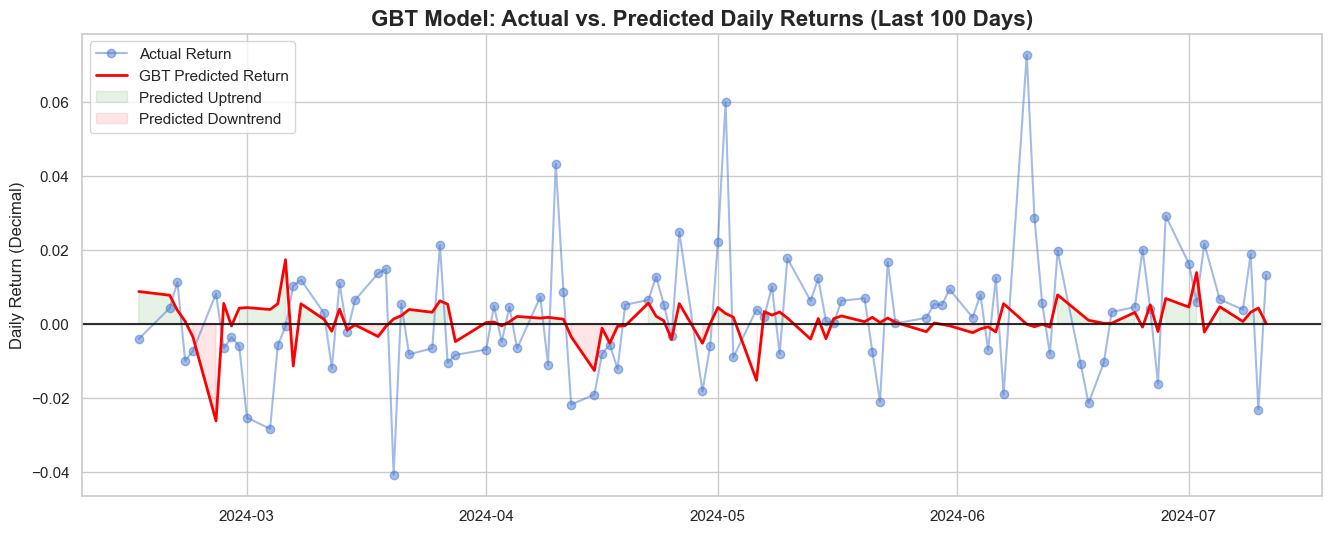

In [12]:
# Visualising the Predictions (Last 100 Days for Clarity)
plot_df = gbt_predictions.select("Date", "Target_Next_Return", "gbt_prediction").tail(100)
plot_pdf = pd.DataFrame(plot_df, columns=["Date", "Actual_Return", "Predicted_Return"])

plt.figure(figsize=(16, 6))
plt.plot(plot_pdf["Date"], plot_pdf["Actual_Return"], label="Actual Return", marker='o', alpha=0.5)
plt.plot(plot_pdf["Date"], plot_pdf["Predicted_Return"], label="GBT Predicted Return", color='red', linewidth=2)
plt.axhline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.8)
plt.fill_between(plot_pdf["Date"], 0, plot_pdf["Predicted_Return"], where=(plot_pdf["Predicted_Return"] > 0), color='green', alpha=0.1, label='Predicted Uptrend')
plt.fill_between(plot_pdf["Date"], 0, plot_pdf["Predicted_Return"], where=(plot_pdf["Predicted_Return"] < 0), color='red', alpha=0.1, label='Predicted Downtrend')
plt.title("GBT Model: Actual vs. Predicted Daily Returns (Last 100 Days)", fontsize=16, fontweight='bold')
plt.ylabel("Daily Return (Decimal)")
plt.legend(loc="upper left")
plt.savefig('aapl_predictions.png')
plt.show()


## 📊 7. Dashboard-Style Results and Visual Analytics

This section turns the model outputs into a lightweight **dashboard-style analytics layer**.

**Why this matters:**  
In FinTech, a model is not enough on its own. Analysts, risk teams, and decision-makers need:
- key performance indicators (KPIs),
- visual trends,
- anomaly flags,
- and interactive summaries.

This final section helps students move from **distributed processing** to **decision-oriented analytics**.

In [13]:
# CELL 7.1 — Convert Spark predictions to Pandas for dashboard-style visualisation
dashboard_df = gbt_predictions.select(
    "Date",
    "Close",
    "Target_Next_Return",
    "gbt_prediction",
    "Volume",
    "PERatio",
    "EPS",
    "MarketCap"
).toPandas()

dashboard_df["Date"] = pd.to_datetime(dashboard_df["Date"])
dashboard_df = dashboard_df.sort_values("Date").reset_index(drop=True)

print("Dashboard Data Shape:", dashboard_df.shape)
dashboard_df.head()

26/05/03 11:56:05 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 11:56:05 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 11:56:05 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 11:56:05 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 11:56:05 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 11:56:05 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 1

Dashboard Data Shape: (1242, 8)


,Date,Close,Target_Next_Return,gbt_prediction,Volume,PERatio,EPS,MarketCap
0,2019-08-05,193.34,0.018930,0.002891,52392969.0,35.85,6.43,3.535123e+12
1,2019-08-06,197.00,0.010355,-0.013486,35824787.0,35.85,6.43,3.535123e+12
2,2019-08-07,199.04,0.022056,-0.000996,33364400.0,35.85,6.43,3.535123e+12
3,2019-08-08,203.43,-0.011994,0.001378,27009523.0,35.85,6.43,3.535123e+12
4,2019-08-09,200.99,-0.002537,-0.004406,24619746.0,35.85,6.43,3.535123e+12


In [14]:
# CELL 7.2 — Dashboard KPIs
from IPython.display import display, Markdown

total_rows = len(dashboard_df)
avg_actual_return = dashboard_df["Target_Next_Return"].mean()
avg_pred_return = dashboard_df["gbt_prediction"].mean()
avg_volume = dashboard_df["Volume"].mean()
latest_close = dashboard_df["Close"].iloc[-1]

display(Markdown("## 📌 Dashboard KPIs"))
display(Markdown(f"- Total records analysed: **{total_rows:,}**"))
display(Markdown(f"- Latest closing price: **{latest_close:,.2f}**"))
display(Markdown(f"- Average actual next-day return: **{avg_actual_return:.6f}**"))
display(Markdown(f"- Average predicted next-day return: **{avg_pred_return:.6f}**"))
display(Markdown(f"- Average trading volume: **{avg_volume:,.0f}**"))

## 📌 Dashboard KPIs

- Total records analysed: **1,242**

- Latest closing price: **227.57**

- Average actual next-day return: **0.000836**

- Average predicted next-day return: **0.000464**

- Average trading volume: **72,095,613**

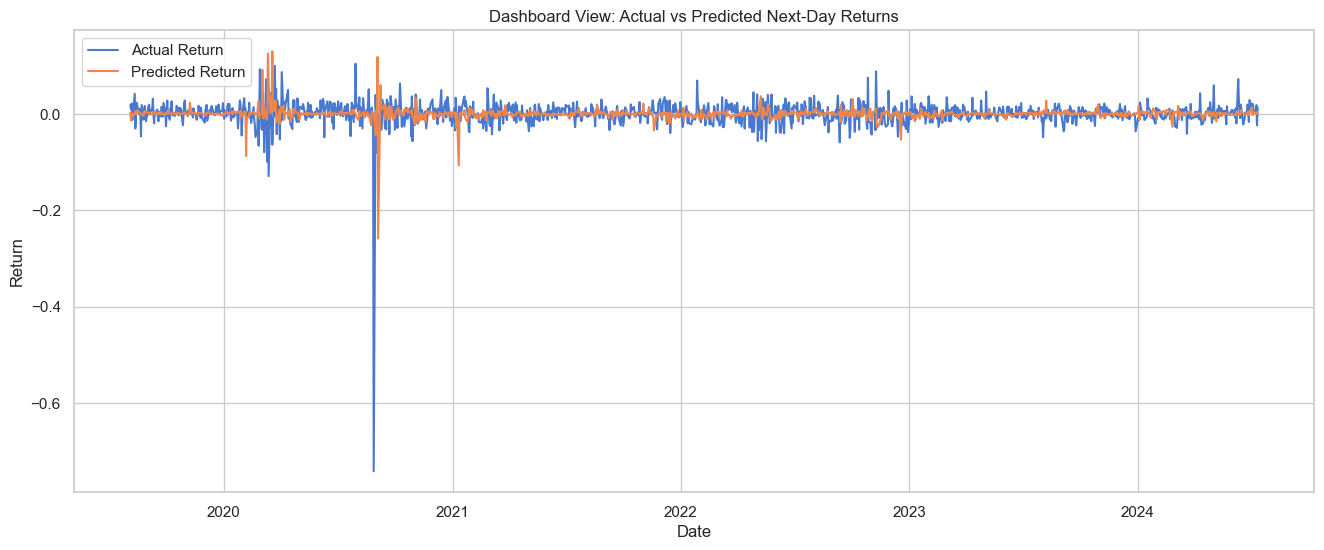

In [15]:
# CELL 7.3 — Time-series dashboard: actual vs predicted returns
plt.figure(figsize=(16, 6))
plt.plot(dashboard_df["Date"], dashboard_df["Target_Next_Return"], label="Actual Return")
plt.plot(dashboard_df["Date"], dashboard_df["gbt_prediction"], label="Predicted Return")
plt.title("Dashboard View: Actual vs Predicted Next-Day Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.grid(True)
plt.show()

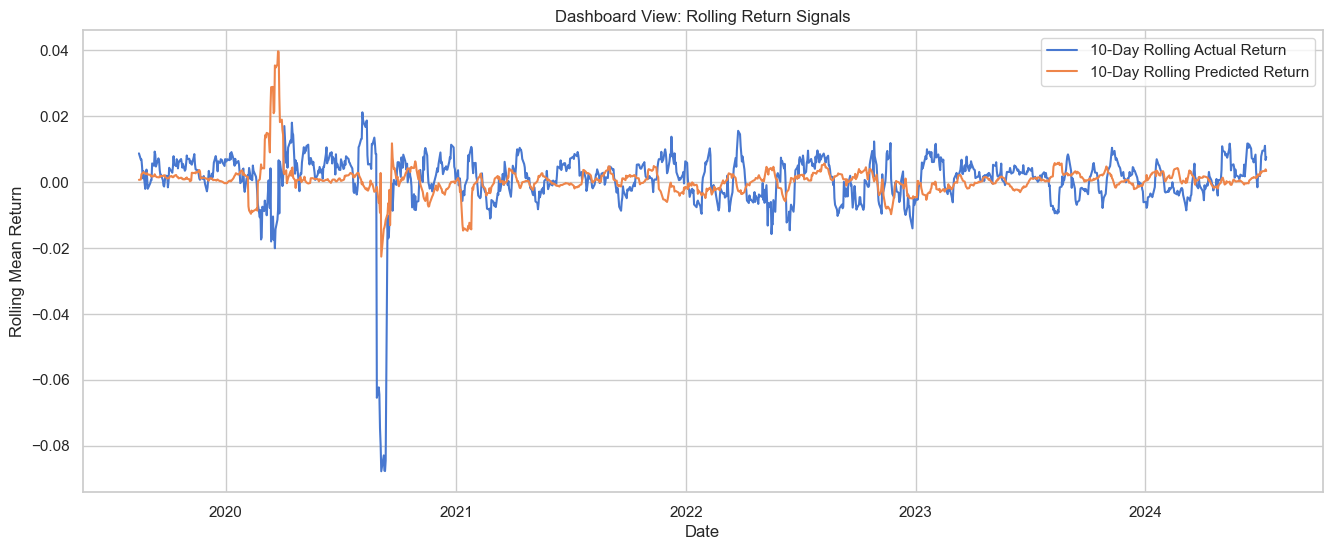

In [16]:
# CELL 7.4 — Rolling behaviour dashboard
dashboard_df["Rolling_Actual_10"] = dashboard_df["Target_Next_Return"].rolling(window=10).mean()
dashboard_df["Rolling_Pred_10"] = dashboard_df["gbt_prediction"].rolling(window=10).mean()

plt.figure(figsize=(16, 6))
plt.plot(dashboard_df["Date"], dashboard_df["Rolling_Actual_10"], label="10-Day Rolling Actual Return")
plt.plot(dashboard_df["Date"], dashboard_df["Rolling_Pred_10"], label="10-Day Rolling Predicted Return")
plt.title("Dashboard View: Rolling Return Signals")
plt.xlabel("Date")
plt.ylabel("Rolling Mean Return")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
# CELL 7.5 — Simple anomaly dashboard using Z-score threshold on returns
returns_mean = dashboard_df["Target_Next_Return"].mean()
returns_std = dashboard_df["Target_Next_Return"].std()

dashboard_df["Return_ZScore"] = (
    (dashboard_df["Target_Next_Return"] - returns_mean) / returns_std
)

anomalies_df = dashboard_df[dashboard_df["Return_ZScore"].abs() > 2].copy()

print(f"Number of anomalous return days detected: {len(anomalies_df)}")
anomalies_df[["Date", "Target_Next_Return", "Return_ZScore"]].head(10)

Number of anomalous return days detected: 21


,Date,Target_Next_Return,Return_ZScore
141,2020-02-26,-0.065368,-2.273860
143,2020-02-28,0.093101,3.168938
148,2020-03-06,-0.079092,-2.745225
149,2020-03-09,0.072022,2.444954
151,2020-03-11,-0.098755,-3.420557
152,2020-03-12,0.119808,4.086241
153,2020-03-13,-0.128647,-4.447243
157,2020-03-19,-0.063486,-2.209199
159,2020-03-23,0.100325,3.417079
168,2020-04-03,0.087237,2.967560


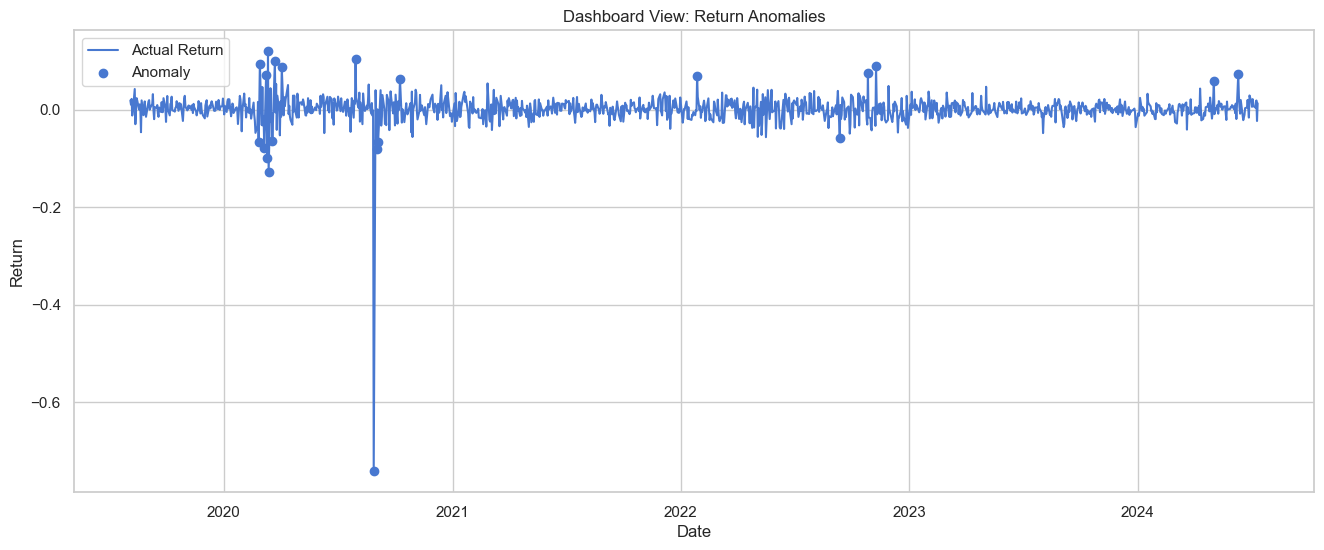

In [18]:
# CELL 7.6 — Visual anomaly dashboard
plt.figure(figsize=(16, 6))
plt.plot(dashboard_df["Date"], dashboard_df["Target_Next_Return"], label="Actual Return")
plt.scatter(anomalies_df["Date"], anomalies_df["Target_Next_Return"], label="Anomaly")
plt.title("Dashboard View: Return Anomalies")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
# CELL 7.7 — Interactive dashboard chart (Plotly)
import plotly.express as px

fig = px.line(
    dashboard_df,
    x="Date",
    y=["Target_Next_Return", "gbt_prediction"],
    title="Interactive Dashboard: Actual vs Predicted Returns"
)
fig.show()

In [20]:
# CELL 8.1 — Stop Spark (always run last)
spark.stop()
print("✅ Spark session stopped. Lab complete!")
print("\n📁 Saved output files available in Colab directory:")
for f in [
    "aapl_price_volume.png",
    "aapl_returns_distribution.png",
    "aapl_correlation.png",
    "aapl_predictions.png"
]:
    if os.path.exists(f):
        print(f" - {f}")


✅ Spark session stopped. Lab complete!

📁 Saved output files available in Colab directory:
 - aapl_price_volume.png
 - aapl_returns_distribution.png
 - aapl_correlation.png
 - aapl_predictions.png
